# Clean Pipeline — minimal

**Model:** Llama-3.1-8B-Instruct · **Framework:** Crescendo · **Train:** JBB · **Test:** WildJailbreak (WJB)

Three sections, position-conditional labels (Zhao split):

* **`t_inst`** → harmful vs benign goal.
* **`t_post`** → among harmful goals only: successful vs failed attack, success measured by `aisi_scaled ≥ 0.5` (StrongReject/AISI).

Final turn only. All 8 layers. No compressed, no per-turn curves.

## 0. Setup

In [ ]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

REPO = Path("/Users/lisahusieva/Desktop/multi-turn-rep-eng")
DATA = REPO / "data" / "llama"
FIG  = REPO / "figures"; FIG.mkdir(exist_ok=True)

LAYER_INFO   = json.load(open(DATA / "representations" / "trajectories" / "crescendo_harmful" / "layer_indices.json"))
LAYER_LABELS = LAYER_INFO["labels"]            # ['L1','L5','L9','L14','L18','L23','L27','L32']
N_LAYERS     = len(LAYER_LABELS)
POSITIONS    = ["t_inst", "t_post"]

AISI_THRESHOLD = 0.5   # success iff aisi_scaled >= AISI_THRESHOLD

def load(rel):
    d = DATA / rel
    return (
        pd.read_parquet(d / "metadata.parquet"),
        np.load(d / "h_inst.npy",      mmap_mode="r"),
        np.load(d / "h_post_inst.npy", mmap_mode="r"),
    )

# Seven blocks: JBB single-turn (h/b) + JBB full-context harmful (for t_post training)
# + WJB full/no-context (h/b).
BLOCKS = {
    ("JBB", "single_turn",  "harmful"): load("representations/single_turn/harmful"),
    ("JBB", "single_turn",  "benign" ): load("representations/single_turn/benign"),
    ("JBB", "full_context", "harmful"): load("representations/trajectories/crescendo_harmful"),
    ("WJB", "full_context", "harmful"): load("representations_wj/trajectories/crescendo_harmful"),
    ("WJB", "full_context", "benign" ): load("representations_wj/trajectories/crescendo_benign"),
    ("WJB", "no_context",   "harmful"): load("representations_wj/nocontext/crescendo_harmful"),
    ("WJB", "no_context",   "benign" ): load("representations_wj/nocontext/crescendo_benign"),
}

# AISI success lookup: (conversation_id, attempt) -> bool, using the StrongReject CSVs.
def aisi_lookup(csv_path: Path) -> dict:
    sr = pd.read_csv(csv_path)
    sr = sr[sr.framework == "crescendo"]
    return {(c, int(a)): float(s) >= AISI_THRESHOLD
            for c, a, s in zip(sr.conversation_id, sr.attempt, sr.aisi_scaled)}

AISI_JBB = aisi_lookup(DATA / "sr_final_scores.csv")
AISI_WJB = aisi_lookup(DATA / "sr_final_scores_wj.csv")

for k, (m, hi, hp) in BLOCKS.items():
    print(f"{k}: rows={len(m):>6}  h_inst={hi.shape}")
print(f"AISI lookups: JBB={len(AISI_JBB)} convos, WJB={len(AISI_WJB)} convos")

In [ ]:
def vecs(key, position, layer_idx, rows=None):
    """Return float32 (n, hidden) matrix for a block at (layer, position)."""
    _, hi, hp = BLOCKS[key]
    arr = hi if position == "t_inst" else hp
    if rows is None:
        rows = np.arange(arr.shape[0])
    return np.asarray(arr[rows, layer_idx, :], dtype=np.float32)

def final_turn_rows(key):
    """One row per conversation: the row with the highest turn_k."""
    m = BLOCKS[key][0]
    return m.groupby("conversation_id")["turn_k"].idxmax().values

def success_mask(key, rows, aisi):
    """Boolean array of length len(rows): True iff the conversation succeeded under AISI."""
    m = BLOCKS[key][0].iloc[rows]
    return np.array([aisi.get((c, int(a)), False) for c, a in zip(m.conversation_id, m.attempt)])

## 1. Direction `v_ST[layer, pos]` per position

* **t_inst** — topic-paired mean difference on JBB **single-turn**: `mean(harmful) − mean(benign)` per `pair_id`, averaged.
* **t_post** — topic-paired mean difference on JBB **full-context final turn** (harmful only): `mean(success) − mean(failure)` per `pair_id`, averaged. Topics with no contrast (all-success or all-failure) are skipped.

Each direction is unit-normalized.

In [ ]:
mh_st = BLOCKS[("JBB", "single_turn", "harmful")][0]
mb_st = BLOCKS[("JBB", "single_turn", "benign" )][0]
TOPICS_ST = sorted(set(mh_st.pair_id) & set(mb_st.pair_id))

def v_inst(layer_idx):
    """harmful − benign on JBB single-turn at t_inst."""
    diffs = []
    for t in TOPICS_ST:
        rh = mh_st.index[mh_st.pair_id == t].to_numpy()
        rb = mb_st.index[mb_st.pair_id == t].to_numpy()
        h = vecs(("JBB", "single_turn", "harmful"), "t_inst", layer_idx, rh).mean(axis=0)
        b = vecs(("JBB", "single_turn", "benign" ), "t_inst", layer_idx, rb).mean(axis=0)
        diffs.append(h - b)
    v = np.stack(diffs).mean(axis=0)
    return v / np.linalg.norm(v)


# Build success/failure pools on JBB full-context final turn (harmful only).
key_jbb_full_h = ("JBB", "full_context", "harmful")
rows_jbb_final = final_turn_rows(key_jbb_full_h)
mask_jbb_succ  = success_mask(key_jbb_full_h, rows_jbb_final, AISI_JBB)
m_jbb_final    = BLOCKS[key_jbb_full_h][0].iloc[rows_jbb_final].reset_index(drop=False).rename(columns={"index": "row"})
m_jbb_final["success"] = mask_jbb_succ
n_succ, n_fail = int(mask_jbb_succ.sum()), int((~mask_jbb_succ).sum())
print(f"JBB full-context final-turn harmful: {len(rows_jbb_final)} convos, {n_succ} success / {n_fail} fail (AISI≥{AISI_THRESHOLD})")

TOPICS_POST = sorted(m_jbb_final.pair_id.unique())

def v_post(layer_idx):
    """success − failure on JBB full-context final-turn harmful at t_post."""
    diffs = []
    for t in TOPICS_POST:
        sub = m_jbb_final[m_jbb_final.pair_id == t]
        rs  = sub.loc[sub.success, "row"].to_numpy()
        rf  = sub.loc[~sub.success, "row"].to_numpy()
        if len(rs) == 0 or len(rf) == 0:
            continue
        s = vecs(key_jbb_full_h, "t_post", layer_idx, rs).mean(axis=0)
        f = vecs(key_jbb_full_h, "t_post", layer_idx, rf).mean(axis=0)
        diffs.append(s - f)
    v = np.stack(diffs).mean(axis=0)
    return v / np.linalg.norm(v)


v_ST = {}
for L in range(N_LAYERS):
    v_ST[(L, "t_inst")] = v_inst(L)
    v_ST[(L, "t_post")] = v_post(L)
print("built", len(v_ST), "directions")

## 2. AUROC of the 1-D projection

For each `(layer, position, condition)`, score each WJB final-turn example as
`s = h · v_ST` and compute AUROC against the position-conditional label.

* **t_inst** — harmful vs benign on WJB final turn.
* **t_post** — success vs failure on WJB **harmful** final turn (success = `aisi_scaled ≥ 0.5`).

Centering by `c` is a constant offset and doesn't affect AUROC, so we skip it.

* **Plot 1** — AUROC by layer, two lines per panel (`no_context` vs `full_context`). Answers: where is the single-turn axis linearly readable, and does multi-turn context degrade it?
* **Plot 2** — `AUROC(full_context) − AUROC(no_context)` by layer. Negative = displacement; near zero = context didn't matter; positive = context helped.

In [ ]:
def auroc_at(layer_idx, position, condition):
    """AUROC of projection s = h · v_ST against the position-conditional label, on WJB final turn."""
    v = v_ST[(layer_idx, position)]
    if position == "t_inst":
        # harmful vs benign over WJB final turn.
        rh = final_turn_rows(("WJB", condition, "harmful"))
        rb = final_turn_rows(("WJB", condition, "benign" ))
        sh = vecs(("WJB", condition, "harmful"), "t_inst", layer_idx, rh) @ v
        sb = vecs(("WJB", condition, "benign" ), "t_inst", layer_idx, rb) @ v
        scores = np.concatenate([sh, sb])
        labels = np.concatenate([np.ones(len(sh)), np.zeros(len(sb))]).astype(int)
    else:  # t_post — success vs failure on harmful only.
        key  = ("WJB", condition, "harmful")
        rows = final_turn_rows(key)
        scores = vecs(key, "t_post", layer_idx, rows) @ v
        labels = success_mask(key, rows, AISI_WJB).astype(int)
    return roc_auc_score(labels, scores)


auroc_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        for cond in ("no_context", "full_context"):
            auroc_rows.append({
                "layer":     LAYER_LABELS[L],
                "position":  pos,
                "condition": cond,
                "auroc":     auroc_at(L, pos, cond),
            })
auroc_df = pd.DataFrame(auroc_rows)

# Wide view for inspection.
auroc_wide = (auroc_df
              .pivot_table(index=["position", "layer"], columns="condition", values="auroc")
              .reindex(pd.MultiIndex.from_product([POSITIONS, LAYER_LABELS], names=["position", "layer"])))
auroc_wide["delta"] = auroc_wide["full_context"] - auroc_wide["no_context"]
auroc_wide.round(3)

In [ ]:
# Plot 1: AUROC by layer, two lines per panel (no_context vs full_context).
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, pos, sub in zip(axes, POSITIONS, ["harmful vs benign", "success vs failure (harmful only)"]):
    d_noc  = (auroc_df[(auroc_df.position == pos) & (auroc_df.condition == "no_context")  ]
              .set_index("layer").reindex(LAYER_LABELS).reset_index())
    d_full = (auroc_df[(auroc_df.position == pos) & (auroc_df.condition == "full_context")]
              .set_index("layer").reindex(LAYER_LABELS).reset_index())
    ax.plot(d_noc.layer,  d_noc.auroc,  "o-", color="C0", label="no_context")
    ax.plot(d_full.layer, d_full.auroc, "s-", color="C3", label="full_context")
    ax.axhline(0.5, color="k", lw=0.5)
    ax.set_title(f"{pos}\n{sub}"); ax.set_xlabel("layer"); ax.set_ylim(0.4, 1.02)
axes[0].set_ylabel("AUROC of  s = h · v_ST  on WJB final turn")
axes[1].legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "11_fig1_auroc.png", dpi=150)
plt.show()

In [ ]:
# Plot 2: AUROC(full_context) − AUROC(no_context) by layer — the displacement plot.
delta = (auroc_df
         .pivot_table(index=["layer", "position"], columns="condition", values="auroc")
         .assign(delta=lambda d: d["full_context"] - d["no_context"])
         .reset_index())

fig, ax = plt.subplots(figsize=(7, 4))
for pos, color, marker in (("t_inst", "C2", "o"), ("t_post", "C4", "s")):
    d = (delta[delta.position == pos]
         .set_index("layer").reindex(LAYER_LABELS).reset_index())
    ax.plot(d.layer, d["delta"], marker=marker, color=color, label=pos)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("layer")
ax.set_ylabel("ΔAUROC  =  AUROC(full_context) − AUROC(no_context)")
ax.set_title("Displacement: how much does multi-turn context move the WJB AUROC?")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "11_fig2_delta_auroc.png", dpi=150)
plt.show()

## 2b. Per-turn AUROC

Same `v_ST`, same labels, same metric — but AUROC is computed at each turn `k`
instead of only the final turn. For each `(layer, position, condition, turn_k)`
we project rows where `turn_k == k` onto `v_ST` and compute AUROC against the
position-conditional label.

* **t_inst** — harmful vs benign at turn `k`.
* **t_post** — success vs failure at turn `k`, on **WJB harmful** only. The
  success label is the *conversation-level* AISI outcome — so this asks
  "does the post-instruction state at turn `k` already predict the eventual
  jailbreak?" rather than a per-turn outcome.

Plots show median ± IQR across the 8 layers (no focal layer pick) and annotate
the per-turn sample size `n`. Sample size drops at later turns because some
WJB conversations end early.

In [31]:
def auroc_per_turn(layer_idx, position, condition):
    """List of (turn_k, auroc, n) at one (layer, position, condition)."""
    v = v_ST[(layer_idx, position)]
    out = []
    if position == "t_inst":
        mh = BLOCKS[("WJB", condition, "harmful")][0]
        mb = BLOCKS[("WJB", condition, "benign" )][0]
        ks = sorted(set(mh.turn_k) & set(mb.turn_k))
        for k in ks:
            rh = mh.index[mh.turn_k == k].to_numpy()
            rb = mb.index[mb.turn_k == k].to_numpy()
            if len(rh) == 0 or len(rb) == 0:
                continue
            sh = vecs(("WJB", condition, "harmful"), "t_inst", layer_idx, rh) @ v
            sb = vecs(("WJB", condition, "benign" ), "t_inst", layer_idx, rb) @ v
            scores = np.concatenate([sh, sb])
            labels = np.concatenate([np.ones(len(sh)), np.zeros(len(sb))]).astype(int)
            out.append({"turn_k": k, "auroc": roc_auc_score(labels, scores),
                        "n": len(labels)})
    else:  # t_post — success vs failure on harmful only
        key = ("WJB", condition, "harmful")
        m   = BLOCKS[key][0]
        for k in sorted(m.turn_k.unique()):
            rows   = m.index[m.turn_k == k].to_numpy()
            scores = vecs(key, "t_post", layer_idx, rows) @ v
            labels = success_mask(key, rows, AISI_WJB).astype(int)
            if len(np.unique(labels)) < 2:
                continue   # AUROC undefined when only one class is present
            out.append({"turn_k": int(k), "auroc": roc_auc_score(labels, scores),
                        "n": len(labels)})
    return out


per_turn_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        for cond in ("no_context", "full_context"):
            for r in auroc_per_turn(L, pos, cond):
                per_turn_rows.append({
                    "layer": LAYER_LABELS[L], "position": pos, "condition": cond, **r,
                })
per_turn_df = pd.DataFrame(per_turn_rows)
per_turn_df.head()

,layer,position,condition,turn_k,auroc,n
0,L1,t_inst,no_context,1,0.626188,1580
1,L1,t_inst,no_context,2,0.648153,1555
2,L1,t_inst,no_context,3,0.658993,1215
3,L1,t_inst,no_context,4,0.615460,861
4,L1,t_inst,no_context,5,0.643592,650


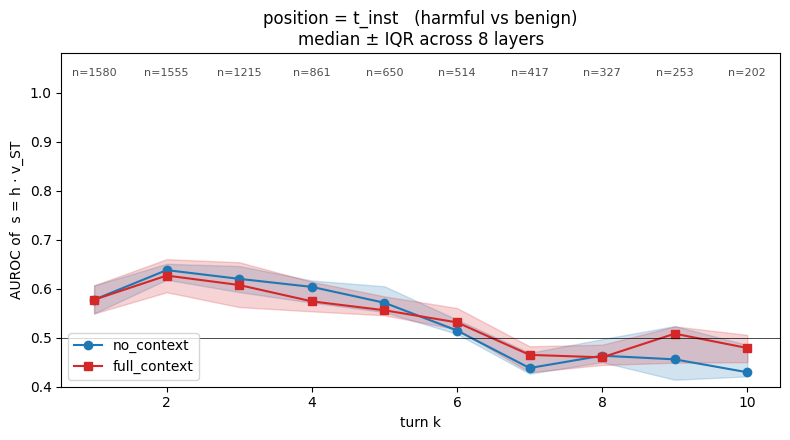

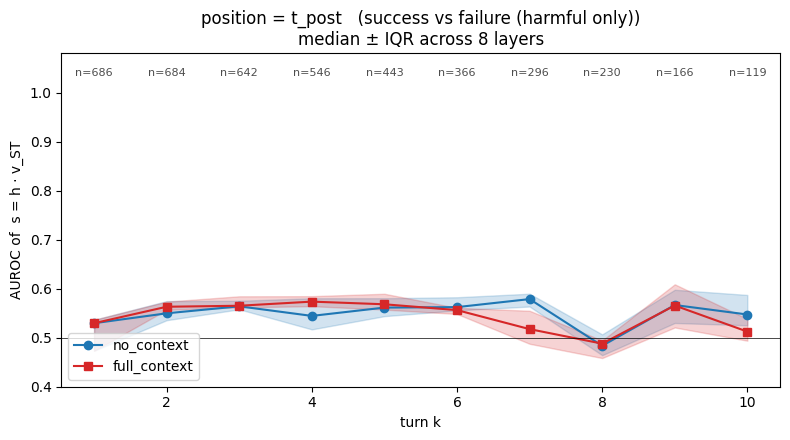

In [32]:
def plot_per_turn(position, sub_label, fname):
    """Median ± IQR AUROC across layers, two lines per condition, n annotated per turn."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sub = per_turn_df[per_turn_df.position == position]
    n_by_turn = {}
    for cond, color, marker in (("no_context", "C0", "o"), ("full_context", "C3", "s")):
        d = sub[sub.condition == cond]
        agg = d.groupby("turn_k")["auroc"].agg(["median",
                                                lambda s: s.quantile(0.25),
                                                lambda s: s.quantile(0.75)])
        agg.columns = ["median", "q25", "q75"]
        agg = agg.sort_index()
        ax.plot(agg.index, agg["median"], marker=marker, color=color, label=cond)
        ax.fill_between(agg.index, agg["q25"], agg["q75"], color=color, alpha=0.2)
        # n per turn: identical across layers within a (cond, turn) pair, take any.
        n_by_turn[cond] = d.groupby("turn_k")["n"].first().sort_index()

    # Annotate n above each turn (use no_context's n; full has the same since conversations are matched).
    n_ref = n_by_turn["no_context"]
    ymax  = 1.02
    ax.set_ylim(0.4, ymax + 0.06)
    for k, n in n_ref.items():
        ax.text(k, ymax + 0.01, f"n={int(n)}", ha="center", va="bottom", fontsize=8, color="0.3")

    ax.axhline(0.5, color="k", lw=0.5)
    ax.set_xlabel("turn k"); ax.set_ylabel("AUROC of  s = h · v_ST")
    ax.set_title(f"position = {position}   ({sub_label})\nmedian ± IQR across 8 layers")
    ax.legend(loc="lower left")
    fig.tight_layout()
    fig.savefig(FIG / fname, dpi=150)
    plt.show()


plot_per_turn("t_inst", "harmful vs benign",                    "11_fig2b_auroc_by_turn_t_inst.png")
plot_per_turn("t_post", "success vs failure (harmful only)",    "11_fig2c_auroc_by_turn_t_post.png")

## 3. Linear vs nonlinear recovery

For each `(layer, position)`, train on JBB and test on WJB **full-context final turn**:

* **t_inst** — train on JBB single-turn harmful vs benign; test on WJB harmful vs benign.
* **t_post** — train on JBB full-context final-turn harmful (success vs failure); test on WJB harmful (success vs failure).

Three models everywhere:

* **M1** — logistic regression on the 1-D projection onto `v_ST`.
* **M2** — L2 logistic regression on the full hidden state.
* **M3** — small MLP `(128,)`, ReLU. Sklearn's `MLPClassifier` has no dropout; `alpha=1e-3` (L2) stands in.

In [33]:
def trainset(position, layer_idx):
    if position == "t_inst":
        Xh = vecs(("JBB", "single_turn", "harmful"), "t_inst", layer_idx)
        Xb = vecs(("JBB", "single_turn", "benign" ), "t_inst", layer_idx)
        X  = np.concatenate([Xh, Xb])
        y  = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
    else:  # t_post
        rows = rows_jbb_final
        X    = vecs(key_jbb_full_h, "t_post", layer_idx, rows)
        y    = mask_jbb_succ.astype(int)
    return X, y

def testset(position, layer_idx):
    if position == "t_inst":
        rh = final_turn_rows(("WJB", "full_context", "harmful"))
        rb = final_turn_rows(("WJB", "full_context", "benign" ))
        Xh = vecs(("WJB", "full_context", "harmful"), "t_inst", layer_idx, rh)
        Xb = vecs(("WJB", "full_context", "benign" ), "t_inst", layer_idx, rb)
        X  = np.concatenate([Xh, Xb])
        y  = np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))]).astype(int)
    else:  # t_post
        key = ("WJB", "full_context", "harmful")
        rows = final_turn_rows(key)
        X = vecs(key, "t_post", layer_idx, rows)
        y = success_mask(key, rows, AISI_WJB).astype(int)
    return X, y


def auc_three_models(layer_idx, position):
    X_tr, y_tr = trainset(position, layer_idx)
    X_te, y_te = testset(position, layer_idx)
    v          = v_ST[(layer_idx, position)]

    # M1: 1-D projection score
    s_tr = (X_tr @ v).reshape(-1, 1)
    s_te = (X_te @ v).reshape(-1, 1)
    m1   = LogisticRegression(max_iter=2000).fit(s_tr, y_tr)
    auc1 = roc_auc_score(y_te, m1.predict_proba(s_te)[:, 1])

    # M2: linear probe on full state
    sc   = StandardScaler().fit(X_tr)
    m2   = LogisticRegression(C=0.1, max_iter=2000).fit(sc.transform(X_tr), y_tr)
    auc2 = roc_auc_score(y_te, m2.predict_proba(sc.transform(X_te))[:, 1])

    # M3: small MLP, 3 seeds
    aucs3 = []
    for seed in (0, 1, 2):
        sc3 = StandardScaler().fit(X_tr)
        m3  = MLPClassifier(hidden_layer_sizes=(128,), activation="relu",
                            alpha=1e-3, max_iter=300, early_stopping=True,
                            validation_fraction=0.1, random_state=seed)
        m3.fit(sc3.transform(X_tr), y_tr)
        aucs3.append(roc_auc_score(y_te, m3.predict_proba(sc3.transform(X_te))[:, 1]))
    return auc1, auc2, float(np.mean(aucs3)), float(np.std(aucs3))


probe_rows = []
for L in range(N_LAYERS):
    for pos in POSITIONS:
        a1, a2, a3, a3s = auc_three_models(L, pos)
        probe_rows.append({"layer": LAYER_LABELS[L], "position": pos,
                           "M1_dir": a1, "M2_lin": a2,
                           "M3_mlp_mean": a3, "M3_mlp_std": a3s})
probe_df = pd.DataFrame(probe_rows)
probe_df.round(3)

,layer,position,M1_dir,M2_lin,M3_mlp_mean,M3_mlp_std
0,L1,t_inst,0.595,0.683,0.467,0.110
1,L1,t_post,0.565,0.556,0.572,0.018
2,L5,t_inst,0.760,0.669,0.644,0.033
3,L5,t_post,0.650,0.587,0.631,0.007
4,L9,t_inst,0.721,0.619,0.625,0.036
5,L9,t_post,0.646,0.614,0.633,0.002
6,L14,t_inst,0.751,0.735,0.624,0.057
7,L14,t_post,0.687,0.611,0.635,0.006
8,L18,t_inst,0.779,0.740,0.659,0.011
9,L18,t_post,0.693,0.589,0.617,0.006


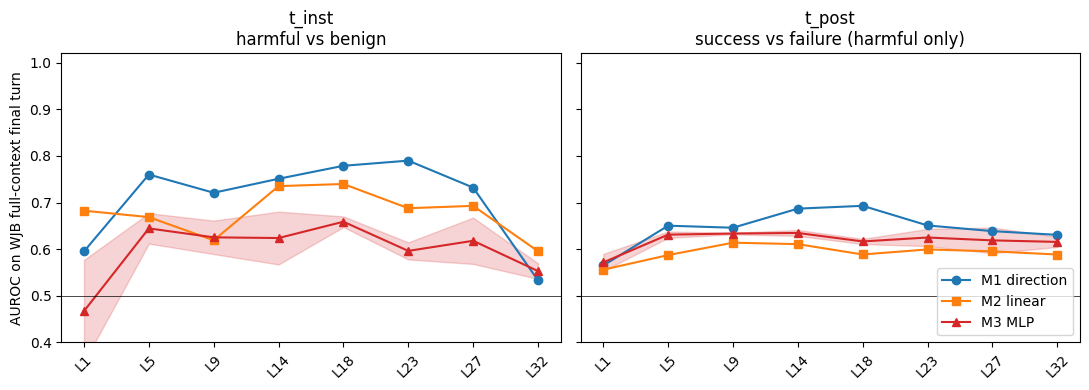

In [34]:
# Figure 3: three models, by layer, faceted by position.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, pos, sub in zip(axes, POSITIONS, ["harmful vs benign", "success vs failure (harmful only)"]):
    d = probe_df[probe_df.position == pos]
    x = np.arange(len(d))
    ax.plot(x, d.M1_dir,      "o-", label="M1 direction", color="C0")
    ax.plot(x, d.M2_lin,      "s-", label="M2 linear",    color="C1")
    ax.plot(x, d.M3_mlp_mean, "^-", label="M3 MLP",       color="C3")
    ax.fill_between(x, d.M3_mlp_mean - d.M3_mlp_std,
                       d.M3_mlp_mean + d.M3_mlp_std, color="C3", alpha=0.2)
    ax.set_xticks(x); ax.set_xticklabels(d.layer, rotation=45)
    ax.set_title(f"{pos}\n{sub}")
    ax.set_ylim(0.4, 1.02); ax.axhline(0.5, color="k", lw=0.5)
axes[0].set_ylabel("AUROC on WJB full-context final turn")
axes[1].legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG / "11_fig3_probes.png", dpi=150)
plt.show()

In [35]:
# Persist results.
out = REPO / "results" / "clean_pipeline"; out.mkdir(parents=True, exist_ok=True)
auroc_df.to_csv(out / "auroc_projection.csv", index=False)
per_turn_df.to_csv(out / "auroc_per_turn.csv", index=False)
probe_df.to_csv(out / "probes.csv", index=False)
print("wrote ->", out)

wrote -> /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/clean_pipeline
